# Modeling Extreme Risk in NIFTY 50: A GARCH-EVT Approach to Value at Risk

---

# Objective:

To develop and backtest robust Value at Risk (VaR) models for the NIFTY 50 index by:

- Capturing heavy-tailed return distributions using Extreme Value Theory (EVT).
- Integrating volatility clustering via GARCH with EVT for improved risk forecasting.
- Statistically validating model performance using violation ratios and Kupiec tests.

---

# Methodology:

- Data Preparation : Analyzed 15 years of daily NIFTY 50 data (2010–2024), and took the log-return.
- Distribution Analysis :
  - Fitted Normal and Student-*t* distributions to returns.
  - Evaluated goodness-of-fit via QQ plots and descriptive statistics.

- Extreme Value Theory (EVT):
  - Isolated left-tail losses below the 5th percentile threshold.
  - Modeled excess losses using Generalized Pareto Distribution (GPD):

- Pure EVT VaR: Direct GPD-based tail estimation.
- Hybrid GARCH-EVT VaR :
  - Used GARCH(1,1) to model volatility clustering.
  - Applied EVT to GARCH-standardized residuals.
  - Scaled residuals by forecasted volatility for dynamic VaR.

- Backtesting :
  - Used violation ratio and Kupiec test to validate VaR calibration.

---

# Key Findings:

- Return Characteristics:
  - Heavy tails (kurtosis = 13.74) and right-skew (skewness = 0.94).
- Student-*t*:
  - (df = 4.11) outperformed Normal distribution in capturing tail risk.
- GPD Tail Fit Diagnostics (QQ plots, mean excess) confirmed tail suitability.

- VaR Performance at 99.9% confidence level
  - Expected model violation is 3, which is actually achieved in GARCH-EVT model, while in simple EVT model actual violation is 8. GARCH-EVT significantly outperformed pure EVT. Statistically valid at 95% confidence (Kupiec p > 0.05).

- Backtest Visualization : GARCH-EVT VaR dynamically adapted to volatility spikes, while pure EVT underestimated risk.

---

# Conclusions:

- Market Realities : NIFTY 50 returns exhibit significant non-normality, necessitating specialized tail-risk models.
- Model Superiority : GARCH-EVT hybrid is the superior approach. Combines short-term volatility dynamics (GARCH) with extreme tail modeling (EVT).
- Delivers statistically reliable VaR estimates for 99.9% confidence.
- Practical Implications: Pure EVT underestimates risk during volatility clusters.
- GARCH-EVT is recommended for:
  - Portfolio risk management in Indian equities.
  - Regulatory capital calculations (e.g., Basel III).

---

# Code:


Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from scipy.stats import norm, t, genpareto, skew, kurtosis, chi2
from sklearn.metrics import r2_score

from statsmodels.distributions.empirical_distribution import ECDF
import statsmodels.api as sm

In [2]:
df=pd.read_csv("NIFTY 50_Historical_PR_01012010to31122024.csv")
df.head()

,Index Name,Date,Open,High,Low,Close
0,NIFTY 50,31 Dec 2024,23560.6,23689.85,23460.45,23644.80
1,NIFTY 50,30 Dec 2024,23796.9,23915.35,23599.30,23644.90
2,NIFTY 50,27 Dec 2024,23801.4,23938.85,23800.60,23813.40
3,NIFTY 50,26 Dec 2024,23775.8,23854.50,23653.60,23750.20
4,NIFTY 50,24 Dec 2024,23769.1,23867.65,23685.15,23727.65


In [3]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [4]:
df["Return"]=np.log(df["Close"]/df["Close"].shift(1))
df=df["Return"]
df.dropna(inplace=True)

Summary statistics:
Mean: -0.00040546004781941153
Std Dev: 0.010550954489049282
Skewness: 0.9425790888242449
Kurtosis: 13.741609686781107
Normal fit: mu = -0.000405, std = 0.010550
Student-t fit: df = 4.11, mu = 0.000000, std = 0.007465
R^2 for Normal fit: 0.8865
R^2 for Student-t fit: 0.9077


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


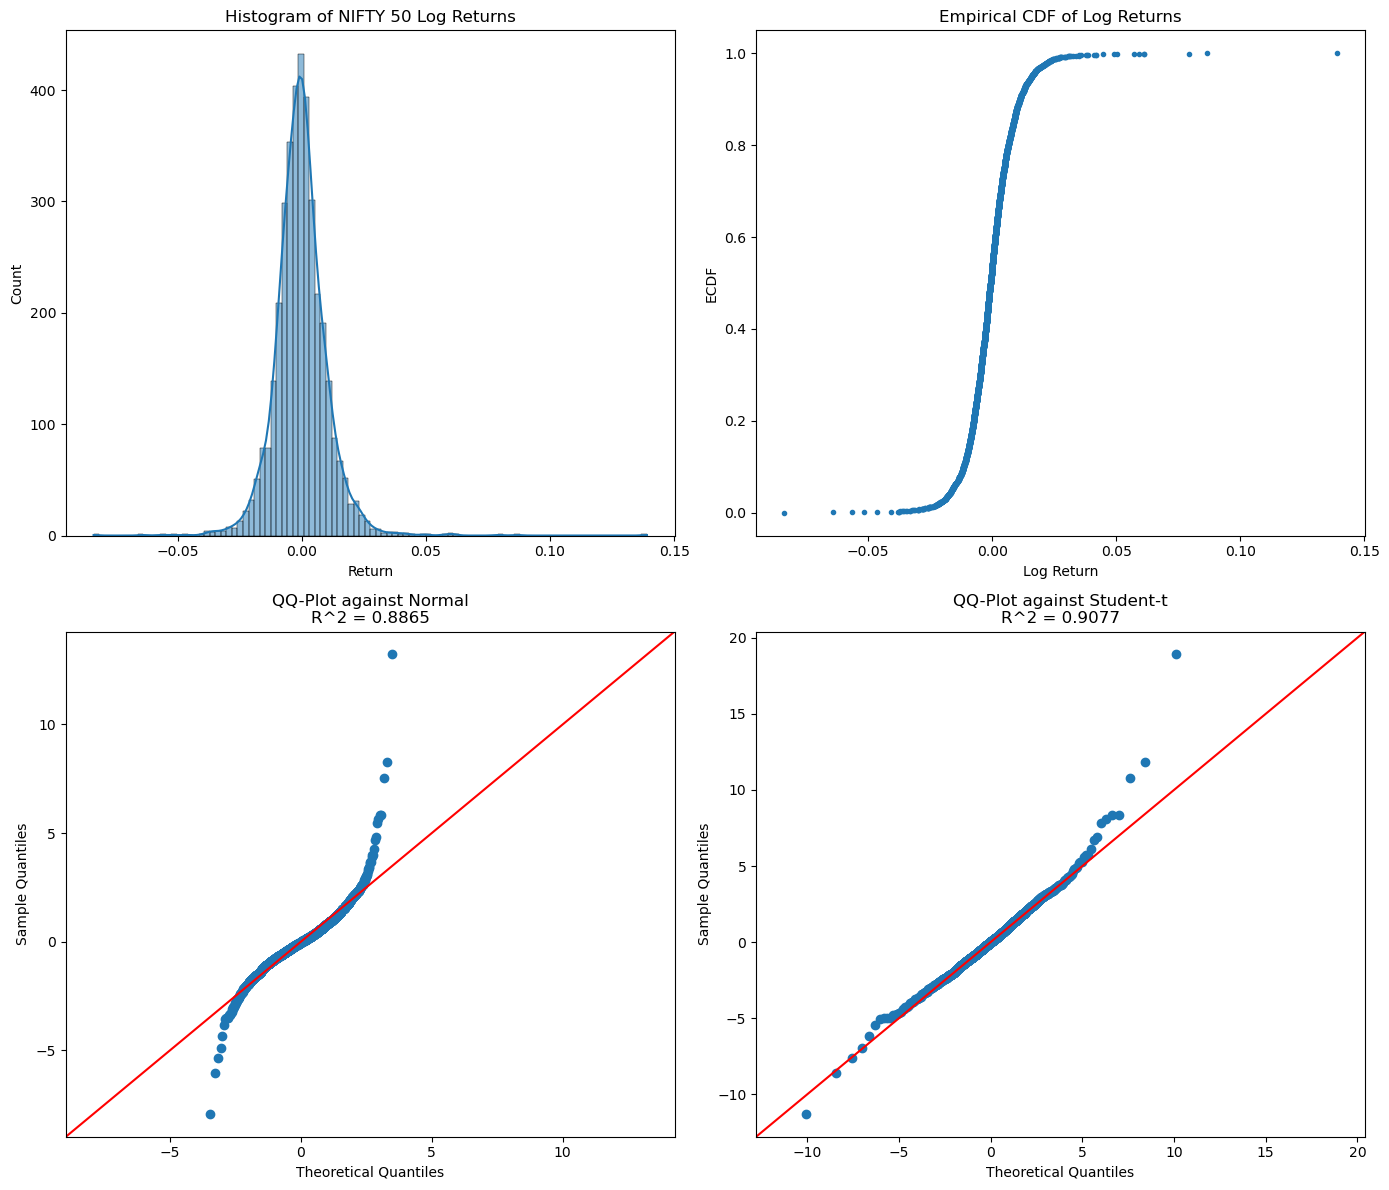

In [5]:
returns = df


print("Summary statistics:")
print(f"Mean: {returns.mean()}")
print(f"Std Dev: {returns.std()}")
print(f"Skewness: {skew(returns)}")
print(f"Kurtosis: {kurtosis(returns)}")


mu_norm, std_norm = norm.fit(returns)
df_t, mu_t, std_t = t.fit(returns, floc=0)

print(f"Normal fit: mu = {mu_norm:.6f}, std = {std_norm:.6f}")
print(f"Student-t fit: df = {df_t:.2f}, mu = {mu_t:.6f}, std = {std_t:.6f}")


returns_sorted = np.sort(returns)
quantiles = np.linspace(0.01, 0.99, len(returns_sorted))


norm_theoretical = norm.ppf(quantiles, loc=mu_norm, scale=std_norm)
t_theoretical = t.ppf(quantiles, df=df_t, loc=mu_t, scale=std_t)


r2_norm = r2_score(returns_sorted, norm_theoretical)
r2_t = r2_score(returns_sorted, t_theoretical)

print(f"R^2 for Normal fit: {r2_norm:.4f}")
print(f"R^2 for Student-t fit: {r2_t:.4f}")


ecdf = ECDF(returns)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))


sns.histplot(returns, bins=100, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histogram of NIFTY 50 Log Returns")

# ECDF
axes[0, 1].plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
axes[0, 1].set_title("Empirical CDF of Log Returns")
axes[0, 1].set_xlabel("Log Return")
axes[0, 1].set_ylabel("ECDF")


sm.qqplot(returns, dist=norm, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title(f'QQ-Plot against Normal\nR^2 = {r2_norm:.4f}')


sm.qqplot(returns, dist=t, distargs=(df_t,), line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title(f'QQ-Plot against Student-t\nR^2 = {r2_t:.4f}')

plt.tight_layout()
#plt.savefig("normal-t-fit-r2.png")
plt.show()

Conclusions: The Student-t distribution fits the NIFTY50 log returns better than the Normal distribution, as indicated by a higher $R^2$ (0.907 vs. 0.886). Its low degrees of freedom $\approx$ 4 ) capture the heavy tails observed in the data (kurtosis $\approx$ 13.74), making it more suitable for modeling extreme returns and tail risk.

Plotting excesses and fitted GPD PDF for left tail for visualization

R² for GPD left-tail fit: 0.9281


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


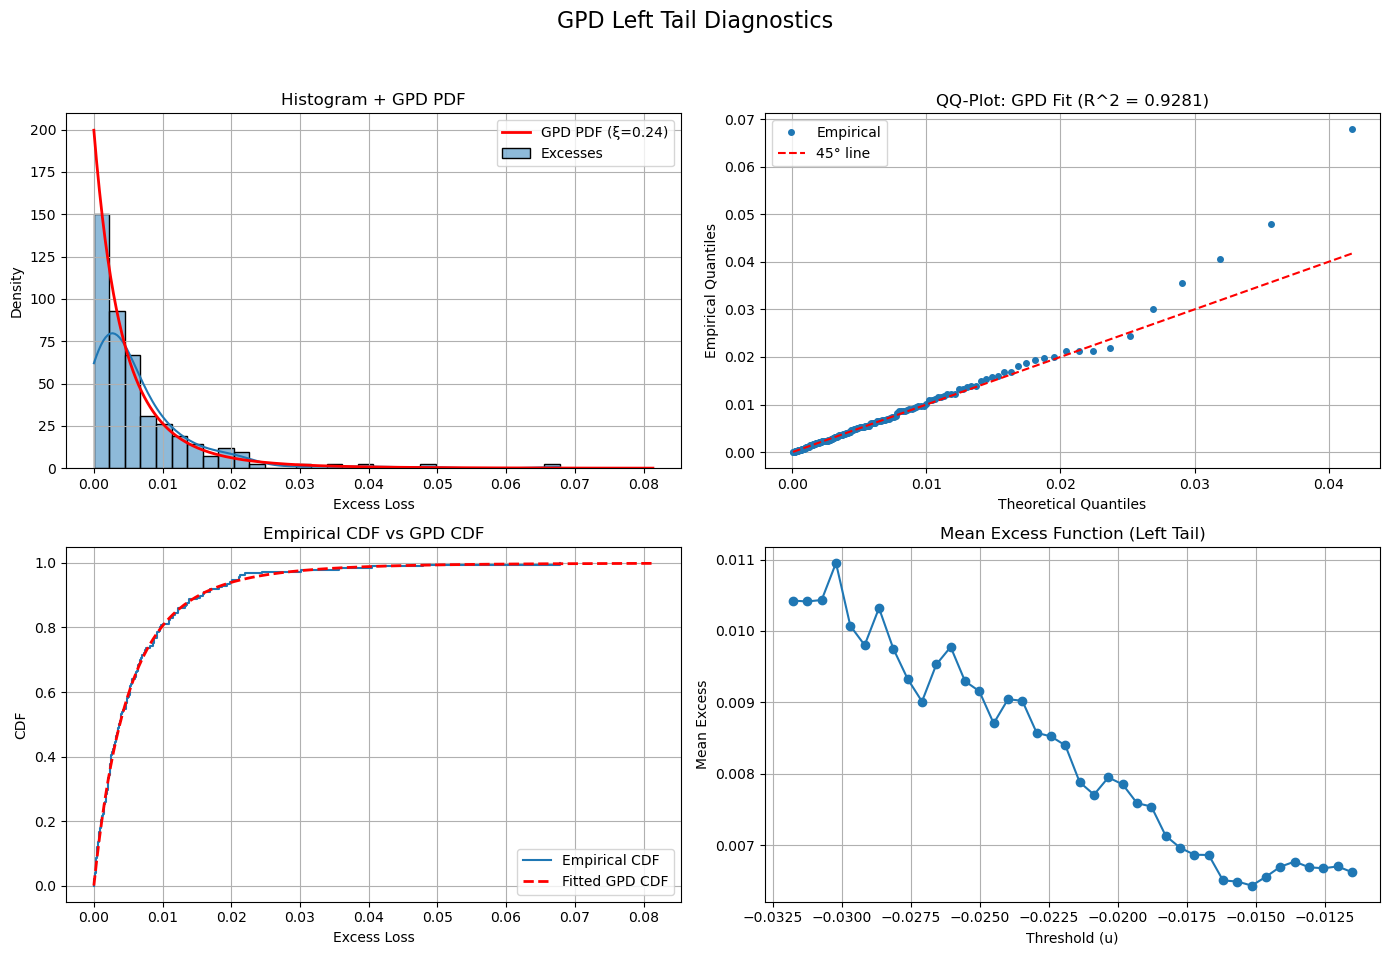

In [6]:
threshold_left = np.percentile(returns, 5)
excess_left = threshold_left - returns[returns < threshold_left]


shape_left, loc_left, scale_left = genpareto.fit(excess_left, floc=0)

emp_excess = np.sort(excess_left)
quantiles = np.linspace(0.01, 0.99, len(emp_excess))
theor_excess = genpareto.ppf(quantiles, c=shape_left, loc=0, scale=scale_left)


r2_gpd = r2_score(emp_excess, theor_excess)
print(f"R² for GPD left-tail fit: {r2_gpd:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GPD Left Tail Diagnostics", fontsize=16)


x = np.linspace(0, max(excess_left) * 1.2, 200)
pdf_fitted = genpareto.pdf(x, c=shape_left, loc=0, scale=scale_left)
sns.histplot(excess_left, bins=30, stat='density', ax=axes[0, 0], label='Excesses', kde=True)
axes[0, 0].plot(x, pdf_fitted, 'r-', lw=2, label=f'GPD PDF (ξ={shape_left:.2f})')
axes[0, 0].set_title("Histogram + GPD PDF")
axes[0, 0].set_xlabel("Excess Loss")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()
axes[0, 0].grid(True)


emp_excess = np.sort(excess_left)
theor_q = genpareto.ppf(np.linspace(0.01, 0.99, len(emp_excess)), c=shape_left, loc=0, scale=scale_left)
axes[0, 1].plot(theor_q, emp_excess, 'o', markersize=4, label='Empirical')
axes[0, 1].plot(theor_q, theor_q, 'r--', label='45° line')
axes[0, 1].set_title(f"QQ-Plot: GPD Fit (R^2 = {r2_gpd:.4f})")
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Empirical Quantiles")
axes[0, 1].legend()
axes[0, 1].grid(True)


ecdf = ECDF(excess_left)
cdf_vals = genpareto.cdf(x, c=shape_left, loc=0, scale=scale_left)
axes[1, 0].step(ecdf.x, ecdf.y, where='post', label='Empirical CDF')
axes[1, 0].plot(x, cdf_vals, 'r--', lw=2, label='Fitted GPD CDF')
axes[1, 0].set_title("Empirical CDF vs GPD CDF")
axes[1, 0].set_xlabel("Excess Loss")
axes[1, 0].set_ylabel("CDF")
axes[1, 0].legend()
axes[1, 0].grid(True)


thresholds = np.linspace(np.percentile(returns, 0.5), np.percentile(returns, 10), 40)
mean_excess = []
for u in thresholds:
    tail = returns[returns < u]
    if len(tail) > 0:
        mean_excess.append(np.mean(u - tail))
    else:
        mean_excess.append(np.nan)

axes[1, 1].plot(thresholds, mean_excess, marker='o')
axes[1, 1].set_title("Mean Excess Function (Left Tail)")
axes[1, 1].set_xlabel("Threshold (u)")
axes[1, 1].set_ylabel("Mean Excess")
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.savefig("gpd_fit.png")
plt.show()


We modeled the left tail of NIFTY 50 log returns using a Generalized Pareto Distribution (GPD) for excess losses beyond the 5th percentile. The fitted GPD aligns well with the empirical histogram and ECDF, and the QQ plot shows a good match for most quantiles, with minor underestimation of extreme losses. The mean excess function is approximately linear above the threshold, supporting the use of GPD in this region. The goodness-of-fit is further confirmed by a high $R^2$ value of 0.9281. Overall, the GPD is a reasonable choice for modeling left-tail risk and estimating high-confidence risk measures like Value at Risk (VaR).

In [7]:
def compute_evt_var(data, alpha, threshold_pct):
    threshold = np.percentile(data, threshold_pct)
    tail_data = threshold - data[data < threshold]  # excesses



    shape, loc, scale = genpareto.fit(tail_data, floc=0)
    p_tail = len(tail_data) / len(data)

    q = genpareto.ppf(1 - alpha / p_tail, c=shape, loc=0, scale=scale)
    return threshold - q

In [8]:
def Var_evt_fun(data, window, alpha, threshold_pct):
    VaRs = []
    violations = []
    idx = data.index[window:]
    for i in range(window, len(data)):
        window_data = returns.iloc[i - window:i]
        VaR_window = compute_evt_var(window_data, alpha, threshold_pct)
        VaRs.append(VaR_window)
        violations.append(returns.iloc[i] < VaR_window)
    return pd.DataFrame({
        'VaR': VaRs,
        'Violation': violations
    }, index=idx)

In [9]:
def garch_evt_var(data, window, alpha, threshold_pct):
    model = arch_model(data * 100, vol='Garch', p=1, q=1, dist='normal')
    res = model.fit(update_freq=0, disp='off')

    cond_vol = res.conditional_volatility / 100
    std_resids = returns / cond_vol.shift(1)

    VaRs = []
    violations = []
    idx = data.index[window:]

    for i in range(window, len(returns)):
        resids_window = std_resids.iloc[i - window:i].dropna()
        var_std = compute_evt_var(resids_window, alpha, threshold_pct)
        var_actual = var_std * cond_vol.iloc[i]
        VaRs.append(var_actual)
        violations.append(returns.iloc[i] < var_actual)

    return pd.DataFrame({'VaR': VaRs, 'Violation': violations}, index=idx)


In [10]:
alpha = 0.001
threshold_pct = 10
window = 500
VaR_GARCH_EVT = garch_evt_var(returns, window, alpha, threshold_pct)
VaR_EVT = Var_evt_fun(returns, window, alpha, threshold_pct)

The Violation Ratio (VR) checks if the actual number of VaR breaches aligns with expectations:

$$VR = \frac{x}{n\cdot \alpha}$$
where:
- x=Actual VaR breaches
- n=Total observations
- $\alpha$=VaR confidence level (e.g., for 99% VaR,=0.01).
  
Interpretation:
- VR $\approx$ 1: Well-calibrated model
- VR > 1: Underestimates risk (too optimistic)
- VR < 1: Overestimates risk (too conservative) - Commonly, violation ratio in the range of $[0.8, 1.2]$ considered as good.

In [11]:
n_vio_evt = VaR_EVT["Violation"].sum()
n_vio_GE = VaR_GARCH_EVT["Violation"].sum()
n_total = len(VaR_EVT)

In [12]:
print(f"VaR EVT\n Actual violation: {n_vio_evt},  Expected violation: {int(alpha * n_total)}, violation ratio : {round(n_vio_evt/(alpha*n_total),2)} ")

print(f"VaR GARCH+EVT\n Actual violation: {n_vio_GE},  Expected violation: {int(alpha * n_total)}, violation ratio : {round(n_vio_GE/(alpha*n_total),2)} ")

VaR EVT
 Actual violation: 8,  Expected violation: 3, violation ratio : 2.48 
VaR GARCH+EVT
 Actual violation: 3,  Expected violation: 3, violation ratio : 0.93 


From a violation ratio perspective, the GARCH+EVT-based VaR model is significantly better calibrated compared to the simple EVT-based VaR model.

Plot the Value at Risk (VaR) alongside the actual returns to perform a backtest.

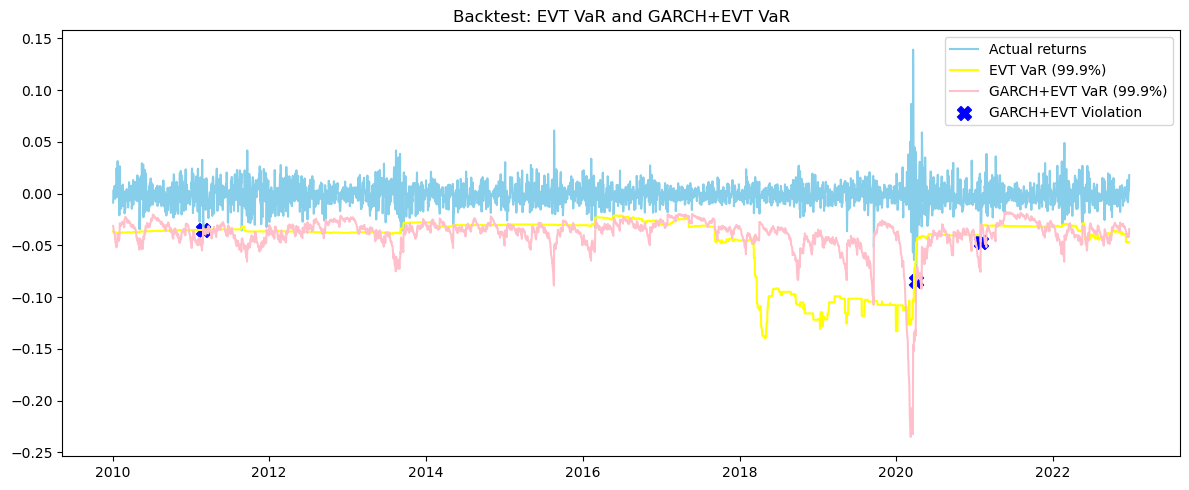

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(returns.iloc[500:], label="Actual returns", color="skyblue")
plt.plot(VaR_EVT["VaR"], label="EVT VaR (99.9%)", color="yellow")
plt.plot(VaR_GARCH_EVT["VaR"], label="GARCH+EVT VaR (99.9%)", color="pink")

plt.scatter(VaR_GARCH_EVT.index[VaR_GARCH_EVT["Violation"]], returns.loc[VaR_GARCH_EVT.index[VaR_GARCH_EVT["Violation"]]],
            color="b", marker="X", s=100, label="GARCH+EVT Violation")
plt.legend()
plt.title("Backtest: EVT VaR and GARCH+EVT VaR")
plt.tight_layout()
plt.show()

In [14]:
VaR_GARCH_EVT.index[VaR_GARCH_EVT["Violation"]]

DatetimeIndex(['2021-01-29', '2020-04-03', '2011-02-28'], dtype='datetime64[ns]', name='Date', freq=None)

### The Kupiec Test:
<br> Also known as the Proportion of Failures (POF) Test, is a statistical test used in Value-at-Risk (VaR) backtesting to verify whether the observed violations (losses exceeding VaR) occur at the expected frequency. It is based on a likelihood ratio (LR) test. <br> The null hypothesis $H_0$ assumes that the proportion of VaR violations matches the expected probability $\alpha$: <br> where:
- $p = \frac{x}{n}$ is the observed proportion of violations,
- $x$ is the number of observed VaR breaches,
- $n$ is the total number of observations,
- $\alpha$ is the expected violation rate (e.g., for 99\% VaR,  $\alpha$ = 0.01).
<br> The *Kupiec likelihood ratio statistic* is given by:
<br> $LR_{POF} = -2 \log \left( \frac{ (1 - \alpha)^{n - x} \alpha^x }{ (1 - p)^{n - x} p^x } \right)$

<br> Under the null hypothesis, $LR_{POF}$ follows a chi-square distribution with one degree of freedom.

<br> Generally, if p-value $> 0.05$ (that is at 95\% confidence level), we fail to reject $H_0$, indicating that the VaR model is correctly calibrated.



In [15]:
def kupiec_test_statistic(n_viol, n_total, alpha=0.01):
    vr = n_viol/n_total
    LR=-2*np.log((((1-alpha)/(1-vr)) ** (n_total-n_viol)) * ((alpha/vr) ** n_viol))
    p_value=1-chi2.cdf(LR, df=1)
    return p_value

In [16]:
print(f"Kupiec test result:\n p-value of simple EVT based VaR : {round(kupiec_test_statistic( n_vio_evt, n_total, alpha),3)}\n p-value of GARCH+EVT based VaR : {round(kupiec_test_statistic( n_vio_GE, n_total, alpha),3)}")

Kupiec test result:
 p-value of simple EVT based VaR : 0.025
 p-value of GARCH+EVT based VaR : 0.901


The p-value for the simple EVT-based VaR model is 0.025, indicating that the model significantly deviates from the expected violation rate and fails to adequately capture tail risk. In contrast, the GARCH+EVT-based VaR model yields a p-value of 0.901, suggesting no significant deviation from the expected violation frequency. Therefore, from a statistical backtesting perspective, the GARCH+EVT model is significantly better calibrated and more reliable for estimating Value at Risk.